<a href="https://colab.research.google.com/github/lkoc0002/MMA3001-Project-Airfoil-Noise-Prediction/blob/main/notebooks/04_Model_Optimising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Model Optimisation and Comparison**

## Purpose

This notebook optimises the Decision Tree Regression and Support Vector
Regression (SVR) models developed previously and compares their final
performance with the multiple linear regression baseline.

The initial Decision Tree achieved strong test performance but fitted the
training data perfectly, indicating potential overfitting. The initial SVR
model showed a smaller training test performance gap but lower predictive
accuracy than the Decision Tree.

The parameters of the model are therefore investigated to determine whether model performance and generalisation can be improved. Parameter selection is performed using cross validation on the training data so that the test data
remain independent for final model evaluation.

The final models are compared using MAE, RMSE and R² on the same withheld
test dataset.

# **Import Libraries and Load Dataset**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
# Define column names because the original dataset has no header row
column_names = [
    "frequency",
    "angle_of_attack",
    "chord_length",
    "free_stream_velocity",
    "displacement_thickness",
    "sound_pressure_level"
]

# Load the experimental dataset from the project GitHub repository
data_url = "https://raw.githubusercontent.com/lkoc0002/MMA3001-Project-Airfoil-Noise-Prediction/refs/heads/main/data/airfoil_self_noise.dat"

df = pd.read_csv(
    data_url,
    sep="\t",
    names=column_names
)

# Separate engineering inputs from the prediction target
X = df[
    [
        "frequency",
        "angle_of_attack",
        "chord_length",
        "free_stream_velocity",
        "displacement_thickness"
    ]
]

y = df["sound_pressure_level"]

In [4]:
# Reproduce the same 80/20 split used in the previous notebooks so final model performance is directly comparable
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 1202
Testing observations: 301


# **Optimising the decison tree model**

## Decision Tree Optimisation

The unrestricted Decision Tree developed previously achieved zero training error but lower performance on the withheld test data. This indicates that the tree may be fitting unnecessary detail within the training observations.

Decision Tree complexity is therefore controlled by investigating several
values of maximum tree depth and minimum samples per leaf.

Five fold cross validation is performed using only the training data. The parameter combination producing the lowest average validation RMSE is selected.

In [5]:
# Candidate parameters used to control Decision Tree complexity
tree_param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_leaf": [1, 2, 5, 10]
}

tree_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=tree_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10, 15, None],
                         'min_samples_leaf': [1, 2, 5, 10]},
             scoring='neg_root_mean_squared_error')

In [6]:
print("Best Decision Tree parameters:")
print(tree_grid.best_params_)

print(
    "Best cross-validation RMSE:",
    round(-tree_grid.best_score_, 3),
    "dB"
)

Best Decision Tree parameters:
{'max_depth': None, 'min_samples_leaf': 1}
Best cross-validation RMSE: 2.591 dB


In [7]:
# Convert cross-validation results into a DataFrame for inspection
tree_cv_results = pd.DataFrame(tree_grid.cv_results_)

tree_cv_results[
    [
        "param_max_depth",
        "param_min_samples_leaf",
        "mean_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,param_max_depth,param_min_samples_leaf,mean_test_score,rank_test_score
20,None,1,-2.591049,1
16,15,1,-2.611426,2
21,None,2,-2.835218,3
12,10,1,-2.838756,4
17,15,2,-2.839808,5
13,10,2,-2.953651,6
18,15,5,-3.211470,7
22,None,5,-3.211470,7
14,10,5,-3.258098,9
8,7,1,-3.576159,10


### Decision Tree Optimisation Results

The grid search selected max_depth = None and min_samples_leaf = 1, with a
five-fold cross-validation RMSE of approximately 2.59 dB. These parameters are equivalent to the original unrestricted Decision Tree.

None of the tested restrictions on tree complexity improved the average
cross validation RMSE. Although the selected tree continues to fit the training data perfectly, the cross validation results do not provide evidence that the tested complexity restrictions improve predictive performance. The cross validation selected unrestricted tree is therefore retained for final comparison.

# **Evaluating Decision Tree model**

In [8]:
# Retrieve the best model selected using training-data cross-validation
best_tree = tree_grid.best_estimator_

tree_train_pred = best_tree.predict(X_train)
tree_test_pred = best_tree.predict(X_test)

tree_train_mae = mean_absolute_error(y_train, tree_train_pred)
tree_train_rmse = np.sqrt(mean_squared_error(y_train, tree_train_pred))
tree_train_r2 = r2_score(y_train, tree_train_pred)

tree_test_mae = mean_absolute_error(y_test, tree_test_pred)
tree_test_rmse = np.sqrt(mean_squared_error(y_test, tree_test_pred))
tree_test_r2 = r2_score(y_test, tree_test_pred)

tree_results = pd.DataFrame({
    "Metric": ["MAE (dB)", "RMSE (dB)", "R²"],
    "Training": [
        tree_train_mae,
        tree_train_rmse,
        tree_train_r2
    ],
    "Testing": [
        tree_test_mae,
        tree_test_rmse,
        tree_test_r2
    ]
})

tree_results

,Metric,Training,Testing
0,MAE (dB),0.0,1.734007
1,RMSE (dB),0.0,2.424082
2,R²,1.0,0.882708


# **Optimising the Support Vector Regression model**

## Support Vector Regression Optimisation

The initial SVR model improved substantially on the linear regression baseline and showed similar training and testing performance.

SVR performance depends on hyperparameters controlling model flexibility and the influence of individual training observations. The regularisation parameter C, kernel coefficient gamma and epsilon are therefore investigated.

Because SVR is sensitive to feature scale, standardisation is included within a pipeline. This ensures that scaling is fitted independently within each cross validation training fold and prevents information leakage.

In [9]:
# Combine scaling and SVR so preprocessing occurs correctly within
# each cross-validation fold
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

In [10]:
svr_param_grid = {
    "svr__C": [1, 10, 100],
    "svr__gamma": ["scale", 0.01, 0.1, 1],
    "svr__epsilon": [0.1, 0.5, 1.0]
}

svr_grid = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=svr_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

svr_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svr', SVR())]),
             n_jobs=-1,
             param_grid={'svr__C': [1, 10, 100],
                         'svr__epsilon': [0.1, 0.5, 1.0],
                         'svr__gamma': ['scale', 0.01, 0.1, 1]},
             scoring='neg_root_mean_squared_error')

In [11]:
print("Best SVR parameters:")
print(svr_grid.best_params_)

print(
    "Best cross-validation RMSE:",
    round(-svr_grid.best_score_, 3),
    "dB"
)

Best SVR parameters:
{'svr__C': 100, 'svr__epsilon': 0.5, 'svr__gamma': 1}
Best cross-validation RMSE: 2.485 dB


### SVR Optimisation Results

Cross validation selected C=100, epsilon = 0.5 and gamma = 1, with a
five fold cross validation RMSE of approximately 2.49 dB.

The optimised SVR achieved a test RMSE of approximately 2.18 dB and R² of approximately 0.90, compared with a test RMSE of approximately 3.72 dB and R² of approximately 0.72 for the initial SVR. This demonstrates that SVR performance was sensitive to parameter selection and that
cross validation based optimisation substantially improved predictive
performance.

# **Evaluate optimised SVR model**

In [12]:
# Retrieve the SVR configuration selected by cross-validation
best_svr = svr_grid.best_estimator_

svr_train_pred = best_svr.predict(X_train)
svr_test_pred = best_svr.predict(X_test)

svr_train_mae = mean_absolute_error(y_train, svr_train_pred)
svr_train_rmse = np.sqrt(mean_squared_error(y_train, svr_train_pred))
svr_train_r2 = r2_score(y_train, svr_train_pred)

svr_test_mae = mean_absolute_error(y_test, svr_test_pred)
svr_test_rmse = np.sqrt(mean_squared_error(y_test, svr_test_pred))
svr_test_r2 = r2_score(y_test, svr_test_pred)

svr_results = pd.DataFrame({
    "Metric": ["MAE (dB)", "RMSE (dB)", "R²"],
    "Training": [
        svr_train_mae,
        svr_train_rmse,
        svr_train_r2
    ],
    "Testing": [
        svr_test_mae,
        svr_test_rmse,
        svr_test_r2
    ]
})

svr_results

,Metric,Training,Testing
0,MAE (dB),1.035002,1.536642
1,RMSE (dB),1.734514,2.181716
2,R²,0.935873,0.904990


# **Comparing the baseline linear model**

In [15]:
# Refit the original linear regression baseline using the same training data
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_test_pred = linear_model.predict(X_test)

linear_test_mae = mean_absolute_error(y_test, linear_test_pred)
linear_test_rmse = np.sqrt(mean_squared_error(y_test, linear_test_pred))
linear_test_r2 = r2_score(y_test, linear_test_pred)

In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Optimised Decision Tree",
        "Optimised SVR"
    ],
    "MAE (dB)": [
        linear_test_mae,
        tree_test_mae,
        svr_test_mae
    ],
    "RMSE (dB)": [
        linear_test_rmse,
        tree_test_rmse,
        svr_test_rmse
    ],
    "R²": [
        linear_test_r2,
        tree_test_r2,
        svr_test_r2
    ]
})

comparison.round(3)

,Model,MAE (dB),RMSE (dB),R²
0,Linear Regression,3.672,4.704,0.558
1,Optimised Decision Tree,1.734,2.424,0.883
2,Optimised SVR,1.537,2.182,0.905


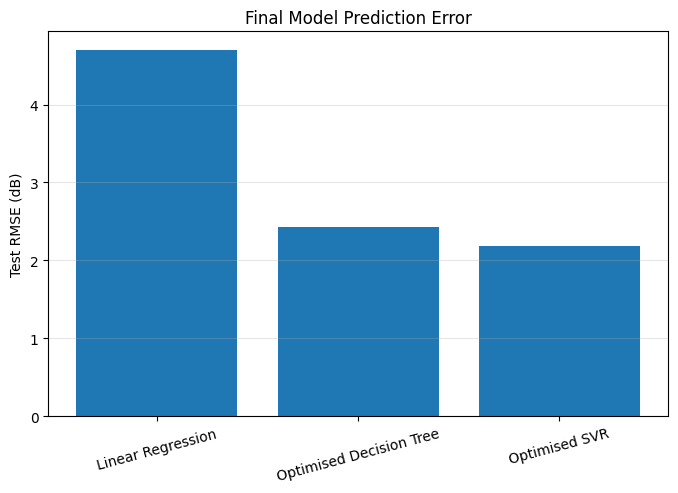

In [17]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["RMSE (dB)"]
)

plt.ylabel("Test RMSE (dB)")
plt.title("Final Model Prediction Error")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Final Model Comparison

The final comparison shows that both nonlinear models substantially reduced
prediction error compared with the linear regression baseline.

Linear Regression produced the highest test RMSE at approximately 4.70 dB. The Decision Tree reduced this to approximately 2.42 dB, while the optimised SVR achieved the lowest test RMSE of approximately 2.18 dB.

The improvement of both nonlinear models over Linear Regression supports the earlier observation that the relationship between the airfoil input variables and sound pressure level is not adequately represented by a simple linear model. Among the models evaluated, the optimised SVR produced the lowest prediction error on the withheld test data.

# **Visualing the optimised SVR model**

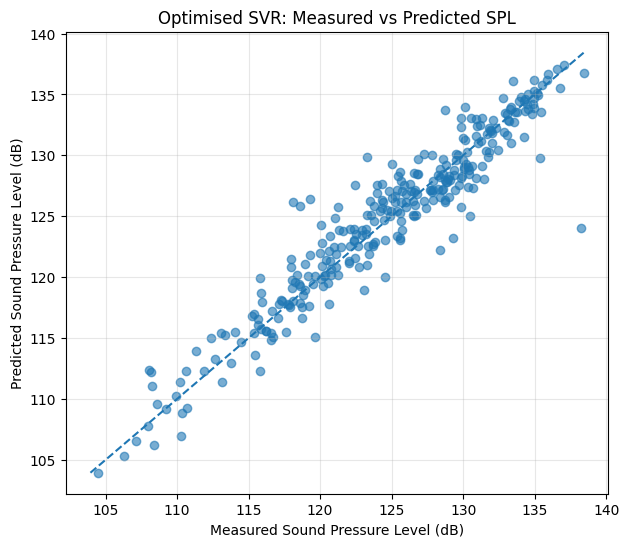

In [18]:
# Compare the final SVR predictions with the experimental measurements
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    svr_test_pred,
    alpha=0.6
)

minimum = min(y_test.min(), svr_test_pred.min())
maximum = max(y_test.max(), svr_test_pred.max())

# Dashed line represents perfect agreement between measurement and prediction
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Measured Sound Pressure Level (dB)")
plt.ylabel("Predicted Sound Pressure Level (dB)")
plt.title("Optimised SVR: Measured vs Predicted SPL")
plt.grid(alpha=0.3)

plt.show()

### Optimised SVR Prediction Results

The measured-versus-predicted plot shows that the optimised SVR predictions generally follow the perfect-prediction reference line closely across the measured sound pressure level range. This visual improvement is consistent with
the reduction in test RMSE from approximately 3.72 dB for the initial SVR to 2.18 dB after optimisation.

Some larger prediction errors remain, including individual observations where the predicted sound pressure level differs substantially from the measured value. Therefore, although optimisation improved overall predictive accuracy, the model does not predict all operating conditions with equal accuracy.

# **Evaluating runtime**

## Computational Cost

Prediction runtime is measured for each final model to provide an indication of computational cost. Since the dataset is relatively small, runtime is not expected to be a limiting factor, however, it provides an additional criterion
for comparing the computational approaches beyond predictive accuracy.

In [22]:
def average_prediction_time(model, X_data, repetitions=100):
    """
    Calculate the average prediction time of a regression model.

    Parameters
    ----------
    model : regression model
        The fitted regression model used to generate predictions.
    X_data : array-like
        The input data used for prediction.
    repetitions : int
        The number of repeated predictions used to calculate the average time.

    Returns
    -------
    average_time : float
        The average prediction time in milliseconds.
    """

    start = time.perf_counter()

    for _ in range(repetitions):
        model.predict(X_data)

    total_time = time.perf_counter() - start
    average_time = (total_time / repetitions) * 1000

    return average_time

# Measure average prediction time for each final model
linear_time = average_prediction_time(
    linear_model,
    X_test
)

tree_time = average_prediction_time(
    best_tree,
    X_test
)

svr_time = average_prediction_time(
    best_svr,
    X_test
)


# Present runtime results for comparison
runtime_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Optimised SVR"
    ],
    "Average Prediction Time (ms)": [
        linear_time,
        tree_time,
        svr_time
    ]
})

runtime_results

,Model,Average Prediction Time (ms)
0,Linear Regression,0.899399
1,Decision Tree,0.852022
2,Optimised SVR,10.116075


### Computational Cost Results

Linear Regression and Decision Tree Regression produced similar average
prediction times of approximately 0.90 ms and 0.85 ms respectively. The
optimised SVR required approximately 10.12 ms for the same test dataset,
making prediction substantially slower than the other two models.

However, the absolute prediction time remained small for all three models.
For the current dataset and intended analysis, the increased computational
cost of SVR is therefore unlikely to be a practical limitation.

This demonstrates a trade off between predictive accuracy and computational
cost. The optimised SVR required greater prediction time but achieved the lowest test RMSE and highest test R² of the models evaluated.

# **Findings**

Model optimisation and comparison showed that nonlinear regression methods provided substantially greater predictive accuracy than the Linear Regression baseline.

The Decision Tree optimisation selected an unrestricted tree with
max_depth = None and min_samples_leaf = 1. This was equivalent to the initial Decision Tree combination and achieved a test RMSE of approximately 2.42 dB and R² of 0.88. Although the model fitted the training data perfectly, the cross validation results did not show that the tested restrictions on tree complexity improved predictive performance.

SVR performance improved substantially following cross validation based parameter optimisation. The selected model used C = 100, epsilon = 0.5 and gamma = 1, achieving a test RMSE of approximately 2.18 dB and R² of 0.90.
This improved on both the initial SVR and the Decision Tree on the withheld
test data.

The optimised SVR required a higher prediction time than Linear Regression and Decision Tree Regression. However, prediction of the test dataset still required only approximately 10 ms on average, so this additional computational cost is small for the present application.

Overall, the optimised SVR provides the strongest predictive performance among the models evaluated while maintaining acceptable computational cost. It is therefore selected for further engineering analysis. However, individual larger prediction errors remain, so model limitations and sensitivity to the input variables will be explored.